In [1]:
# Import Libraries
import time
import sys
import gc
import fitsio
import glob
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import fits
from astropy.io.fits import getheader
from astropy.io.fits.connect import is_fits
from scipy.interpolate import interp1d
from desimodel.footprint import is_point_in_desi
import MockCode as mc
import catalogue_analysis as ca
from cosmology import cosmo
from pathlib import Path

In [2]:
#Set configuration parameters:
#Including:  Whether full Uuchu is read (needs parallel environment) or just pre-made fits subsample

# Configure
date='25thSep'
reg='N'                    #North or South. rancat needs to have been produced for the same region. Consistency is checked
Sel=ca.selection(reg)      #Defines magnitude limits etc for this region
plot = True                #Make some diagnostic plots

obs_seed= 123
sig_lgv = 0.02
min_Vpeak=70.0       #Discard all halos with Vpeak<min_Vpeak. This limits the redshift below which the mock is complete  
N_neigh_vpeak = 1000 #with 1000 the logVpeak scatter among neighbours is < 10^-6 and so will introduce no more than 10^-5 scatter in the magnitude relation
Rejection=False      #Don't use true because as implementedit clearly doesn't work

   
rancat=rf'./sdata/Mocks/rancat{date}_fordata_{reg}.fits' #random catalogue to which the matching is made. It was made by RandomCatalogue.ipynb
subhalo_fits=rf'./sdata/Mocks/subhalos_{reg}_{min_Vpeak:.1f}_seed{obs_seed:03d}_sig_lgv{sig_lgv:.2f}_N_neigh_vpeak{N_neigh_vpeak:4d}.fits'     #file to store a fits version of the selected part of uuchu. If already exists set readfulluuchu=False
mockcat=rf'./sdata/Mocks/mock_{reg}_seed{obs_seed:03d}_sig_lgv{sig_lgv:.2f}.fits'#file to store resulting mock catalogue
randoms_out=rf'./sdata/Mocks/rancat{date}_formock_{reg}.fits' #output random catalogue matching the sky footprint of the output mock



print('Output Checkpoint file:', subhalo_fits)
print('Output Mock catalogue file:', mockcat)
print('Input random catalogue file:', rancat)
print('Output random catalogue file:', randoms_out)


readfulluuchu = False  # If checkpoint file exists and you are not changing obs_seed, sig_lgv, N_neigh_peak or min_Vpeak then this can be set to False and it will run faster and on a login node
usefakesubhalos = False  #Uniform sphere of subhalos for testing purposes
lbox=2000.0           #Box size of Uuchu simulation [0,lbox]
frac_box=0.8     # We cut a sphere of rsphere= frac_box*lbox from 2x2x2 replicas of the simulation cube
rsphere=lbox*frac_box # radius of comoving sphere we cut from the simulation and within which we create the mock  
RAmin = 120          #Region of sky within which we limit the mock.  These cuts are applied before saving subhalo_fits so should not be changed if reusing that dataset.
RAmax = 300
DECmin = 0
DECmax = 90
nzbins=200         #number of redshift windows
N_neigh=50    #Number of neighbours used to define secondary rank used in colour matching 0--> no secondary matching
usemask= True   #use official DR2 mask from the following file
tiles_file = '/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/tiles-BRIGHT.fits'
verbose_stats = False # If true the stats of the subhalo astro-py table are output after every stage
rancat_out = True  #if False don't bother outputting a random catalogue  (one version can suffice for all random seeds and many parameter changes)

Output Checkpoint file: ./sdata/Mocks/subhalos_N_70.0_seed123_sig_lgv0.02_N_neigh_vpeak1000.fits
Output Mock catalogue file: ./sdata/Mocks/mock_N_seed123_sig_lgv0.02.fits
Input random catalogue file: ./sdata/Mocks/rancat25thSep_fordata_N.fits
Output random catalogue file: ./sdata/Mocks/rancat25thSep_formock_N.fits


In [3]:
# North has to be run before South so that South can be downsampled to the North value of NMULT

if (reg == 'S'):
    #See if region N has already been run and if so read the value of NMULT that it has
    #We will later force the NMULT of South to be the same North as otherwise it would be larger
                           
    rancat_formock=rf'./sdata/Mocks/rancat{date}_formock_N.fits' #corresponding random catalogue for region ???
    
    if Path(rancat_formock).exists():
        header = getheader(rancat_formock, ext=1)
        meta = dict(header)
        NMULT_MAX=header['NMULT']
        print('NMULT=', NMULT_MAX)

    else:
        raise RuntimeError(
            f"North must be run before South: {rancat_formock} does not exist"
            )
else:
    NMULT_MAX=1000.0   # effectivley no limit on NMULT
print('NMULT_MAX=',NMULT_MAX)    

NMULT_MAX= 1000.0


In [4]:
#Read the previously saved fits file of the selected sample rather than rereading all of Uuchu
if not readfulluuchu:
    if usefakesubhalos:
        # Number of subhalos
        nsub = 10_000_000
        
        # Random spherical coordinates
        u = np.random.random(nsub)
        r = rsphere * u**(1.0 / 3.0)
        
        cos_theta = np.random.uniform(-1.0, 1.0, nsub)
        sin_theta = np.sqrt(1.0 - cos_theta**2)
        
        phi = np.random.uniform(0.0, 2.0 * np.pi, nsub)
        
        # Cartesian coordinates
        x = r * sin_theta * np.cos(phi)
        y = r * sin_theta * np.sin(phi)
        z = r * cos_theta
        
        # Astropy table
        subhalos = Table()
        subhalos['x'] = x
        subhalos['y'] = y
        subhalos['z'] = z
    
        subhalos['dist']= np.sqrt( (subhalos['x'])**2 + (subhalos['y'])**2 + (subhalos['z'])**2 ) #distance from observer at origin of original box
        subhalos['DEC']= np.degrees(np.arcsin((subhalos['z'])/subhalos['dist']))
        subhalos['RA'] = np.degrees(np.arctan2((subhalos['y']), (subhalos['x']))) % 360
        subhalos['Mpeak_Scale']=np.random.random(nsub)
        subhalos['Vpeak']=np.random.random(nsub)
        subhalos['Mvir_all']=np.random.random(nsub)
        subhalos['FracZpeak']=np.random.random(nsub)
    
        #First build lookup table between comoving distance and redshift
        z_grid = np.linspace(0.0, 1.0, 10000)
        Dc_grid = ca.cosmo.comoving_distance(z_grid).value  # Mpc/h
    
        z_of_Dc = interp1d(
            Dc_grid,
            z_grid,
            bounds_error=False,
            fill_value="extrapolate"
        )
        subhalos['Zu'] = z_of_Dc(subhalos['dist'])
        subhalos['i1'] = np.arange(1, nsub + 1, dtype=np.int32)
        subhalos['ID'] = np.arange(1, nsub + 1, dtype=np.int32)
    else:    
        start_time = time.time()
        subhalos=Table.read(subhalo_fits)
        end_time = time.time()
        
        print(f"time to read saved pre-sorted Uuchu subhalos from fits file: {end_time - start_time:.1f} seconds")
        assert RAmax <= subhalos.meta['RAMAX'], f"RAmax limits not compatible: {RAmax} > {subhalos.meta['RAMAX']}"
        assert RAmin >= subhalos.meta['RAMIN'], f"RAmin limits not compatible: {RAmin} < {subhalos.meta['RAMIN']}"
        assert DECmax <= subhalos.meta['DECMAX'], f"DECmax limits not compatible: {DECmax} > {subhalos.meta['DECMAX']}"
        assert DECmin >= subhalos.meta['DECMIN'], f"DECmmin limits not compatible: {DECmin} < {subhalos.meta['DECMIN']}"
        assert RAmax <= subhalos.meta['RAMAX'], f"RAmax limits not compatible: {RAmax} > {subhalos.meta['RAMAX']}"
        assert min_Vpeak >= subhalos.meta['min_Vpeak'], f"min_Vpeak limits not compatible: {min_Vpeak} < {subhalos.meta['min_Vpeak']}"
        

time to read saved pre-sorted Uuchu subhalos from fits file: 1.8 seconds


In [5]:
#  Read full Uchuu suhbalo catalogue
if readfulluuchu:
    start_time = time.time()
    # Read a sample of the Uuchu subhalos
    index=45 # select redshift snapshot
    redshift = mc.redshift_table[index]

    #Choose random position for observer with seed offset from that used for observer direction
    if (obs_seed==0):
        #If seed=000 place in the centre of the box
        xobs=lbox/2.0
        yobs=lbox/2.0
        zobs=lbox/2.0
    else:    
        # place randomly within the box
        offset=58
        rng = np.random.default_rng((obs_seed+offset))
        xobs = lbox * rng.random()
        yobs = lbox * rng.random()
        zobs = lbox * rng.random()
    print('Observer position:',xobs,yobs,zobs)
    
    # Define the directory containing the halo files
    print("Reading Uuchu data for redshift:",redshift)
    halodir = f"/global/cfs/cdirs/desi/mocks/cai/Uchuu-SHAM/Uchuu-halo-catalogs/halodir_{index:03d}"
    # List all the halo file
    halolist_files = sorted(glob.glob(f'{halodir}/halolist_*.h5'))

    print("number of files to read:",len(halolist_files))

    subhalos = mc.read_halolist_parallel(halolist_files, randseed=0,  columns=('id', 'pid', 'Mvir_all', 'Vpeak', 'x','y','z','vx','vy','vz','Mpeak_Scale', 'Rvir','rs'), 
                                      min_logMvir=9.0, min_Vpeak=min_Vpeak, lbox=lbox, frac_box=frac_box, xobs=xobs, yobs=yobs, zobs=zobs)
    end_time = time.time()
    print(f"time to read Uuchu from disk: {end_time - start_time:.1f} seconds")
    if verbose_stats: subhalos.info('stats')


In [6]:
if readfulluuchu:
    print("A quick look at the data types of the subhalos table before we add RA, DEC and redshift:")
    for k in subhalos.colnames:
        print(k, subhalos[k].dtype)
        
    start_time = time.time()

    #Generate random Euler angle and corresponding rotation matrix
    phi, theta, psi = mc.random_euler_angles(seed=obs_seed)
    print("Euler angles:",phi,theta,psi)
    R = mc.euler_rotation_matrix(phi, theta, psi)
    #Rotate the velocities
    vxr = R[0,0]*subhalos['vx'] + R[0,1]*subhalos['vy'] + R[0,2]*subhalos['vz']
    vyr = R[1,0]*subhalos['vx'] + R[1,1]*subhalos['vy'] + R[1,2]*subhalos['vz']
    vzr = R[2,0]*subhalos['vx'] + R[2,1]*subhalos['vy'] + R[2,2]*subhalos['vz']
    #Overwrite originals and delete temporary arrays    
    subhalos['vx'] = vxr
    subhalos['vy'] = vyr
    subhalos['vz'] = vzr
    del vxr,vyr,vzr
    
                                  
    #Rotate positions 
    xr = R[0,0]*subhalos['x'] + R[0,1]*subhalos['y'] + R[0,2]*subhalos['z']
    yr = R[1,0]*subhalos['x'] + R[1,1]*subhalos['y'] + R[1,2]*subhalos['z']
    zr = R[2,0]*subhalos['x'] + R[2,1]*subhalos['y'] + R[2,2]*subhalos['z']
    #Overwrite originals and delete temporary arrays    
    subhalos['x'] = xr
    subhalos['y'] = yr
    subhalos['z'] = zr
    del xr,yr,zr

    
    end_time = time.time()
    print(f"time to rotate coordinates: {end_time - start_time:.1f} seconds")

    start_time = time.time()
        
    # Compute RA DEC and redshift
    subhalos['dist']= np.sqrt( (subhalos['x'])**2 + (subhalos['y'])**2 + (subhalos['z'])**2 ) #distance from observer at origin of original box
    subhalos['DEC']= np.degrees(np.arcsin((subhalos['z'])/subhalos['dist']))
    subhalos['RA'] = np.degrees(np.arctan2((subhalos['y']), (subhalos['x']))) % 360


    # compute radial velocity over speed of light
    c=299792.458  # speed of light in km/s
    vr_c=( subhalos['x']*subhalos['vx'] + subhalos['y']*subhalos['vy'] + subhalos['z']*subhalos['vz'] ) / (c*subhalos['dist'])

    #Free up space by deleting velocities
    subhalos.remove_column('vx')
    subhalos.remove_column('vy')
    subhalos.remove_column('vz')
    gc.collect() #garbage collection

    #Compute concentration
    subhalos['conc']=subhalos['Rvir']/subhalos['rs']

    #Free up space
    subhalos.remove_column('Rvir')
    subhalos.remove_column('rs')
    gc.collect() #garbage collection

    
    #First build lookup table between comoving distance and redshift
    z_grid = np.linspace(0.0, 1.0, 10000)
    Dc_grid = ca.cosmo.comoving_distance(z_grid).value  # Mpc/h

    z_of_Dc = interp1d(
        Dc_grid,
        z_grid,
        bounds_error=False,
        fill_value="extrapolate"
    )
    subhalos['Zu'] = z_of_Dc(subhalos['dist'])

    subhalos['Zobs'] = (1.0+subhalos['Zu'])*(1.0+vr_c) -1.0
    
    subhalos.rename_column('id', 'ID')
    del z_grid,Dc_grid,z_of_Dc,vr_c
    end_time = time.time()
    print(f"time to compute RA, DEC and redshift: {end_time - start_time:.1f} seconds")
    
if verbose_stats: subhalos.info("stats")

In [7]:
# Sort the subhalo table in decreasing order of Vpeak.
# Define the secondary matching variable FracZpeak with respect to neighbours in Vpeak.
# Add scatter to Vpeak and resort
# set up column 'i1' giving the rank in this ordered table and
# define a column 'keep' if above a distance dependent Vpeak cut    
if readfulluuchu:
    start_time = time.time()
    subhalos= mc.make_all_columns_contiguous(subhalos)
    end_time = time.time()
    print(f"time to make subhalos contiguous: {end_time - start_time:.1f} seconds")
    subhalos=mc.pre_sort_subhalos(subhalos,N_neigh=N_neigh_vpeak,sig_lgv=sig_lgv,plot=plot)  
    if verbose_stats: subhalos.info('stats')

In [8]:
if readfulluuchu:
    start_time = time.time()
    # Reduce the size of the subhalo table by removing the objects with subhalos['keep']=False. Also deletes the 'keep' column
    subhalos = mc.filter_table_staged(subhalos, subhalos['keep'], drop_mask=True, mask_name='keep')
    gc.collect() #garbage collection
    end_time = time.time()
    print(f"time to apply vpeak(distance) cut: {end_time - start_time:.1f} seconds")
    if verbose_stats: subhalos.info('stats')

In [9]:
# Cut to an RA DEC patch or to a mask made to match the DESI data to have a small sample for tests
if usemask:
    tiles = fitsio.read(tiles_file) #read the official tiles/mask file
    if (reg=='N'):
        mask = is_point_in_desi(tiles, subhalos['RA'], subhalos['DEC']) # in whole of official DESI DR2 mask
        mask = mask & (subhalos['RA']>85.0) & (subhalos['RA']<305.0) &  (subhalos['DEC']>32.375) #cut to portion in region North
    else:    
        mask = (subhalos['RA']>85.0) & (subhalos['RA']<305.0) &  (subhalos['DEC']>32.375) # region that includes DESI North and none of DESI South
        mask = ~mask & is_point_in_desi(tiles, subhalos['RA'], subhalos['DEC']) # in whole of official DESI DR2 mask but with ~mask excludes the North
    subhalos= subhalos[mask]
    del mask,tiles

    
else:
    start_time = time.time()
    subhalos["keep"]= (subhalos["RA"]>RAmin)  & (subhalos["RA"]<RAmax) & (subhalos["DEC"]>DECmin)  & (subhalos["DEC"]<DECmax) 
    subhalos = mc.filter_table_staged(subhalos, subhalos['keep'], drop_mask=True, mask_name='keep')
    end_time = time.time()
    print(f"time to apply RA DEC selection: {end_time - start_time:.1f} seconds")


if verbose_stats: subhalos.info("stats")

Uuchu number and box size: 8386889 2000.0


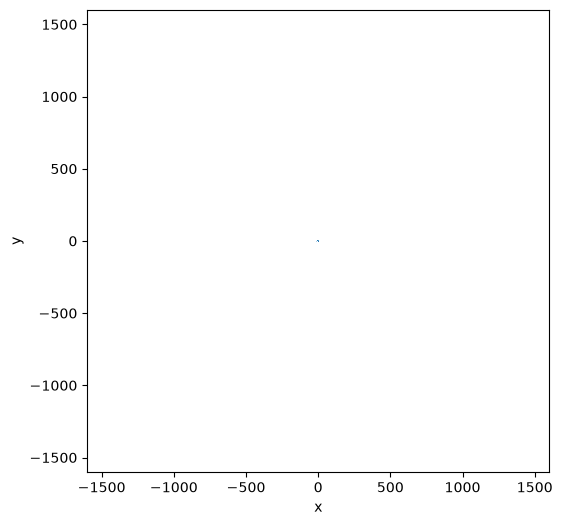

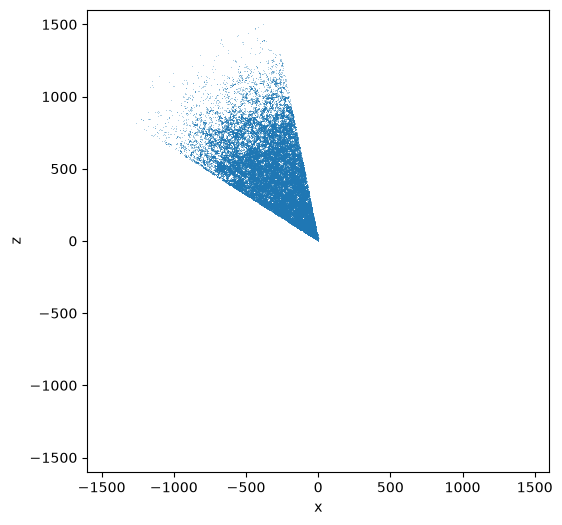

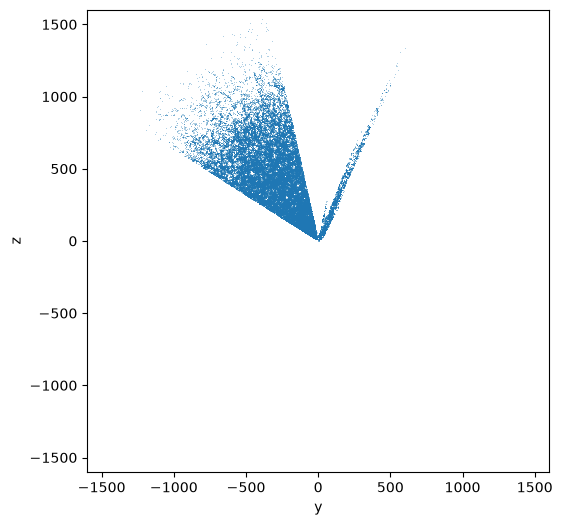

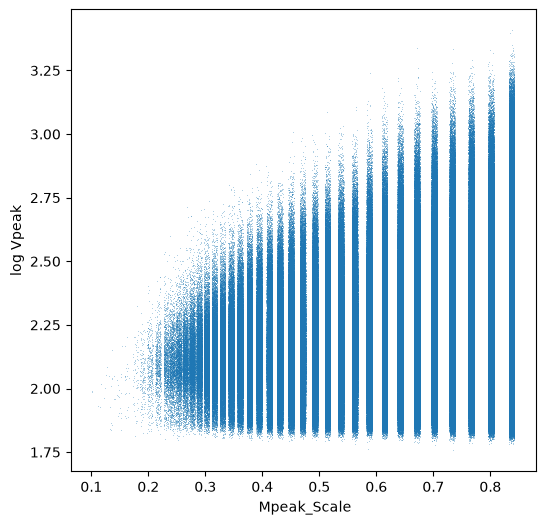

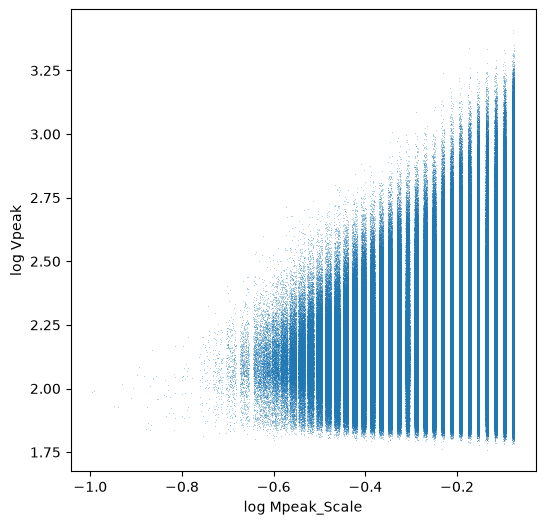

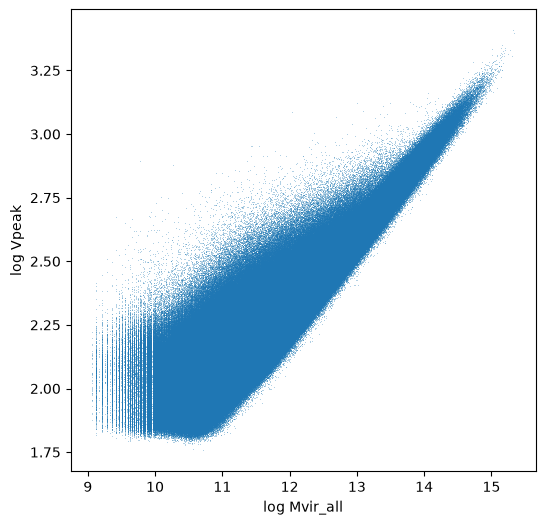

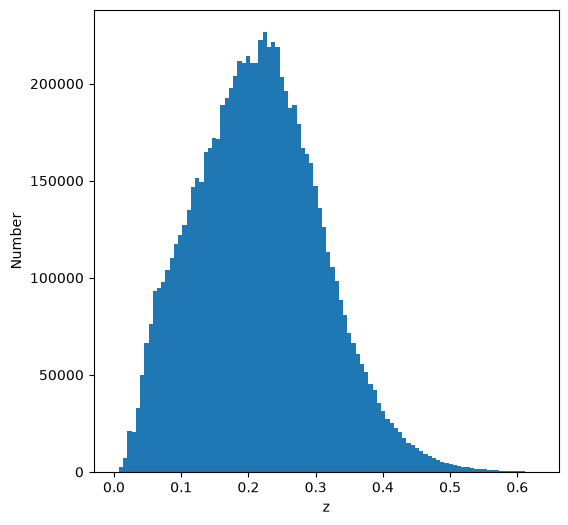

In [10]:
# Inspect uuchu dataset and define the redshift,RA, DEC and other parameters that we may use in matching



nbox=len(subhalos)
print('Uuchu number and box size:',nbox,lbox)



fig, ax = plt.subplots(figsize=(6, 6))
mask = (np.absolute(subhalos['z'])<10.0)
ax.scatter(subhalos['x'][mask],subhalos['y'][mask],marker='.',lw=0,s=0.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-1600,1600)
ax.set_ylim(-1600,1600)
ax.set_aspect("equal")
fig.show()

fig, ax = plt.subplots(figsize=(6, 6))
mask = (np.absolute(subhalos['y'])<10.0)
ax.scatter(subhalos['x'][mask],subhalos['z'][mask],marker='.',lw=0,s=0.5)
ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_xlim(-1600,1600)
ax.set_ylim(-1600,1600)
ax.set_aspect("equal")
fig.show()

fig, ax = plt.subplots(figsize=(6, 6))
mask = (np.absolute(subhalos['x'])<10.0)
ax.scatter(subhalos['y'][mask],subhalos['z'][mask],marker='.',lw=0,s=0.5)
ax.set_xlabel('y')
ax.set_ylabel('z')
ax.set_xlim(-1600,1600)
ax.set_ylim(-1600,1600)
ax.set_aspect("equal")
fig.show()



# Inspect other properties such as the distribution of Vpeak and Mpeak_scale

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(subhalos['Mpeak_Scale'],np.log10(subhalos['Vpeak']),marker='.',lw=0,s=0.5)
ax.set_xlabel(' Mpeak_Scale')
ax.set_ylabel('log Vpeak')
fig.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(np.log10(subhalos['Mpeak_Scale']),np.log10(subhalos['Vpeak']),marker='.',lw=0,s=0.5)
ax.set_xlabel('log Mpeak_Scale')
ax.set_ylabel('log Vpeak')
fig.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(np.log10(subhalos['Mvir_all']),np.log10(subhalos['Vpeak']),marker='.',lw=0,s=0.5)
ax.set_xlabel('log Mvir_all')
ax.set_ylabel('log Vpeak')
fig.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.hist(subhalos['Zu'],bins=100)
ax.set_xlabel('z')
ax.set_ylabel('Number')
fig.show()





In [11]:
#Write selected catalogue to disk for future use
if readfulluuchu:
    start_time = time.time()
    subhalos.meta["RAmin"]=RAmin  #store meta data with subhaloes so consistency can be checked.
    subhalos.meta["RAmax"]=RAmax
    subhalos.meta["DECmin"]=DECmin
    subhalos.meta["DECmax"]=DECmax 
    subhalos.meta["min_Vpeak"]=min_Vpeak 
    subhalos.write(subhalo_fits,overwrite=True)
    end_time = time.time()
    print(f"time to write checkpoint Uchuu catalogue: {end_time - start_time:.1f} seconds")



In [12]:
#Load the random catalogue into a astro-py table
start_time = time.time()
randoms=Table.read(rancat)
print('Meta data',randoms.meta)
nmult=randoms.meta['NMULT'] # This is the factor by which the density is higher in this random catalogue than the corresponding data  
print('nmult=',nmult)
DeltaZ=randoms.meta["DELTAZ"]
print("DeltaZ=",DeltaZ)
regran=randoms.meta["REG"]
print("Random Catalogue was generated with the selection function of region ",regran)
assert regran == reg, f"Faint limits do not match: {regran} != {reg}"
#add and index/id
randoms['ID'] = np.arange(len(randoms), dtype=np.int64)
end_time = time.time()
print(f"time to read Randoms: {end_time - start_time:.1f} seconds")
if verbose_stats: randoms.info('stats')



Meta data {'EXTNAME': 'LSS', 'NMULT': 7, 'DELTAZ': 0.03, 'REG': 'N'}
nmult= 7
DeltaZ= 0.03
Random Catalogue was generated with the selection function of region  N
time to read Randoms: 4.9 seconds


In [13]:
# Adapt the random catalogue to the footprint being used for the mock  
 
nr=len(randoms)
#Generate random RA and DECs within the chosen footprint and estimate its sky coverage at the same time
randoms['RA'],randoms['DEC'],fsky=mc.generate_randoms_in_mask(usemask=usemask,fsky_only=False,nr=nr,tiles_file=tiles_file,reg=reg,RAmin=RAmin,RAmax=RAmax,DECmin=DECmin,DECmax=DECmax)

#Update meta data   
randoms.meta['fsky']=fsky #fraction of sky covered by these randoms
Sel=ca.selection(reg)     
fsky_fordata=Sel['area']  #fraction of sky covered by the original "fordata" randoms
NMULT_formock=randoms.meta['NMULT']*fsky_fordata/fsky #Correct NMULT for difference in sky coverage
randoms.meta['NMULT']=NMULT_formock
print('NMULT=',NMULT_formock,'NMULT_MAX=',NMULT_MAX)
fsky_formock=fsky




Accepted 22,469,196/22,466,277  fsky=0.1088
nr= 22466277
NMULT= 5.968849572560975 NMULT_MAX= 1000.0


In [14]:
print('NMULT=',NMULT_formock,'NMULT_MAX=',NMULT_MAX)
#Force NMULT of S to match that of N by down sampling
if (reg=='S'):
    NTARGET=int(round(len(randoms)*NMULT_MAX/NMULT_formock))
    rng = np.random.default_rng(seed=12345)
    randoms = randoms[rng.choice(len(randoms), size=NTARGET, replace=False)]
    NMULT_formock=NMULT_MAX
    randoms.meta['NMULT']=NMULT_formock
    
#Check stats
randoms.info('stats')
#Print updated meta data
print('Meta data:',randoms.meta)



NMULT= 5.968849572560975 NMULT_MAX= 1000.0
<Table length=22466277>
    name         mean        std         min         max    
------------ ----------- ----------- ----------- -----------
          RA     191.597     52.9404     90.3295     298.303
         DEC     51.4041     12.2722      32.375     79.2802
         reg          --          --          --          --
  ABSMAG_RP1    -20.1908     1.23426    -25.0229    -12.7126
    ABSMAG_R    -20.1837     1.23457    -25.3241    -12.7267
  ABSMAG_GP1    -19.4226     1.13426    -24.9223    -11.7497
REST_GMR_0P1     0.75389    0.205899   -0.196756     1.39771
           v 1.31556e+08 1.52408e+08     10397.9 8.85969e+08
           Z     0.21096   0.0998095        0.01         0.5
        rmag     18.6616    0.831537      10.239       19.54
        gmag     19.6858    0.963119     11.0554     21.5035
        zmin        0.01 5.42968e-16        0.01        0.01
        zmax    0.285664    0.109747   0.0101102         0.5
    TARGETID 3.963

In [15]:
# Abundance match
kcorr_r  = ca.DESI_KCorrection(band='R', file='jmext', photsys=reg) 
Sel=ca.selection(reg)
fsky=randoms.meta['fsky']
nmult=randoms.meta['NMULT']
print(rf"fsky={fsky}  NMULT={nmult}") # factor by which randoms oversampled in the "formock" randoms

z_bins = np.linspace(Sel['zmin'], Sel['zmax'], nzbins)

start_time = time.time()

# Returns the id of each subhalo and the id of the galaxy it is matched with
subhalo_id,galaxy_id = mc.abundance_match_subhalos_to_randoms(
    subhalos=subhalos,
    ran=randoms,
    lbox=lbox,        # simulation box size [Mpc/h]
    rsphere=rsphere,  # radius of sphere cut from the simulation
    fsky=fsky,        # fraction of sky covered by the random galaxy catalogue  
    nmult=nmult,      # oversampling factor of random catalogue
    z_bins=z_bins,    # redshift bin edges
    scatter_sigma=0.0, # dex scatter to add to Vpeak
    DeltaZ=DeltaZ,    #redshift limiter that was used when making the random catalogue
    reg=reg,           #pass in region so correct k-correction can be used
    N_neigh=N_neigh,    #Number of neighbours in luminosity to use when colour matching
    Rejection=Rejection # use ran_zmax>zmin and reject if ran_zmax<z   rather than just ran_max<zmax
)

end_time = time.time()
print(f"Elapsed time finding matches: {end_time - start_time:.4f} seconds")

Reading k-correction polynomials from  .//data//jmext_kcorr_N_rband_z01.dat
fsky=0.10880966585956417  NMULT=5.968849572560975
Reading k-correction polynomials from  .//data//jmext_kcorr_N_rband_z01.dat
fsky=0.10880966585956417  
Global subhalo density in full sphere:  0.0004888237944994055
Visible/Mock ratio = 1.9185319435877923
**WARNING: Subhalo density is insufficient to match the faintest galaxies in the shell resulting Ratio<1.
Processing slice:0.010<z<0.012 Nsubs=1050 Nrans=12024 R=252888.96 Nactual=1050 Nexp=2014.46  Ratio=0.52 nden_sub=0.09238 nden_gal=0.177227 Nran_slice/nmult=2235.94 Nran_vis_slice/nmult=2014.46
Visible/Mock ratio = 1.3301031496208053
**WARNING: Subhalo density is insufficient to match the faintest galaxies in the shell resulting Ratio<1.
Processing slice:0.012<z<0.015 Nsubs=1891 Nrans=25539 R=101923.64 Nactual=1891 Nexp=2554.23  Ratio=0.74 nden_sub=0.11232 nden_gal=0.151716 Nran_slice/nmult=2671.20 Nran_vis_slice/nmult=2515.23
Visible/Mock ratio = 1.16873901

In [16]:
start_time = time.time()
#create numpy array references to the IDs in the Tables
sub_ids = subhalos['ID']
ran_ids = randoms['ID']

# create indices to these arrays so as to put them in order of increasing ID
sub_sorter = np.argsort(sub_ids)
ran_sorter = np.argsort(ran_ids)

# hence produce versions of these arrays in which ID increases monotonically
sub_ids_sorted = sub_ids[sub_sorter]
ran_ids_sorted = ran_ids[ran_sorter]

# Do a vectorized search to find the rows that match the given list of IDs and then use the sorted arrays to map back to their position in the original arrays
sub_rows = sub_sorter[np.searchsorted(sub_ids_sorted, subhalo_id)]
gal_rows = ran_sorter[np.searchsorted(ran_ids_sorted, galaxy_id)]

end_time = time.time()
print(f"Time to unscrammble all the indices: {end_time - start_time:.4f} seconds")

Time to unscrammble all the indices: 1.7810 seconds


In [17]:
# Add galaxy properties to the matched subhalos

#Set up arrays to recieve the values
nsub=len(subhalos)
Mr   = np.full(nsub,np.nan,dtype=np.float32)
Mrobs   = np.full(nsub,np.nan,dtype=np.float32)
rmag =np.full(nsub,np.nan,dtype=np.float32)
Mg   = np.full(nsub,np.nan,dtype=np.float32)
gmag =np.full(nsub,np.nan,dtype=np.float32)
Zr=np.full(nsub,np.nan,dtype=np.float32)
TargetID =np.full(nsub,-1,dtype=randoms['TARGETID'].dtype)

# copy or compute the required quantities for each matched row
Mr[sub_rows] =randoms['ABSMAG_RP1'][gal_rows]
Mrobs[sub_rows] =randoms['ABSMAG_R'][gal_rows]
Mg[sub_rows] =randoms['ABSMAG_GP1'][gal_rows]
Zr[sub_rows] = randoms['Z'][gal_rows]
TargetID[sub_rows] = randoms['TARGETID'][gal_rows]


DMOD=25.0+5.0*np.log10(ca.cosmo.luminosity_distance(randoms['Z'][gal_rows]).value) #compute distance modulus
rest_GMR= randoms['ABSMAG_GP1'][gal_rows]- randoms['ABSMAG_RP1'][gal_rows]  #rest frame colour
kcorr_r  = ca.DESI_KCorrection(band='R', file='jmext', photsys=reg)   #set up r-band k-correction
Qr=Sel['Qr']  #compute r-band magnitude using appropriate k+e correction
rmag[sub_rows]=randoms['ABSMAG_RP1'][gal_rows]+DMOD-Qr*(randoms['Z'][gal_rows]-0.1)+kcorr_r.k(randoms['Z'][gal_rows],rest_GMR)
kcorr_g  = ca.DESI_KCorrection(band='G', file='jmext', photsys=reg)  #set up g-band k-correction
Qg=Sel['Qg'] #compute g-band magnitude using appropriate k+e correction
gmag[sub_rows]=randoms['ABSMAG_GP1'][gal_rows]+DMOD-Qg*(randoms['Z'][gal_rows]-0.1)+kcorr_g.k(randoms['Z'][gal_rows],rest_GMR)
     

#Add arrays to the subhalos table
subhalos["ABSMAG_RP1"]=Mr
subhalos["ABSMAG_R"]=Mrobs
subhalos["ABSMAG_GP1"]=Mg
subhalos["rmag"]=rmag
subhalos["gmag"]=gmag
subhalos["Zr"]=Zr
subhalos["TARGETID"]=TargetID



del DMOD,rest_GMR,Mr,Mg,rmag,gmag,Mrobs,Zr,TargetID # deletes temporary arrays and redundant references

Reading k-correction polynomials from  .//data//jmext_kcorr_N_rband_z01.dat
Reading k-correction polynomials from  .//data//jmext_kcorr_N_gband_z01.dat


In [18]:
# Store the mock catalogue keeping only the subhaloes for which matches were made
mask = np.isfinite(subhalos['rmag'])
subhalos['keep']=mask
subhalos_matched = mc.filter_table_staged(subhalos, subhalos['keep'], drop_mask=True, mask_name='keep')






In [19]:
#Write mock to disk after deleting a couple of columns
subhalos_matched.rename_column('Zu', 'Z') #label the mock redshift as simply Z in the output
subhalos_matched.remove_column('i1')
subhalos_matched.info('stats')
subhalos_matched.write(mockcat,overwrite=True)

<Table length=3736968>
    name        mean        std         min         max    
----------- ----------- ----------- ----------- -----------
         ID 1.48083e+15  2.3708e+14 5.00553e+14 2.08412e+15
        pid 4.21757e+13 7.94031e+13          -1 2.60516e+14
   Mvir_all 5.16162e+12 1.90043e+13 1.14457e+09  1.8992e+15
      Vpeak     249.153     136.143     61.8149     2156.49
          x    -225.927     187.111    -1105.54     243.864
          y    -44.7966     285.236    -1106.05     1029.57
          z     451.637     218.858      16.454     1289.04
Mpeak_Scale    0.744625    0.129769     0.11239     0.84235
       dist     592.283     265.509     29.9181      1316.1
        DEC     51.3257     12.2892      32.375     79.2712
         RA     191.314     52.8344     90.3248      298.27
       conc     13.9894      29.642     1.00039     15196.2
          Z    0.210766   0.0996602   0.0100031    0.499999
       Zobs    0.210836   0.0995962  0.00805116    0.508172
  FracZpeak    0.

In [20]:
# Write the corresponding randoms
# after deleting columns that aren't useful
randoms.remove_column('reg')
randoms.remove_column('v')
randoms.remove_column('zmin')
randoms.remove_column('ID')
randoms.remove_column('TARGETID')

gc.collect()

randoms.write(randoms_out,overwrite=True)

NMULT= 5.968849572560975 5.968849572560975


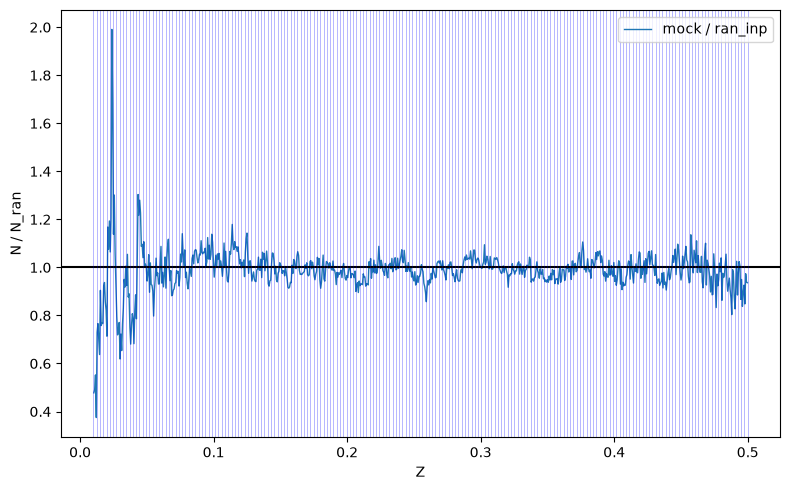

In [21]:
#Look at ratio of N(z) of the mock compared to the target randoms

z_bins = np.linspace(Sel['zmin'],Sel['zmax'], 800)
mock=Table.read(mockcat)

print('NMULT=',randoms.meta['NMULT'],NMULT_formock)

# Histograms
h_ran, edges     = np.histogram(randoms['Z'], bins=z_bins)
h_ran=h_ran/(fsky_formock*NMULT_formock)
h_mock, _    = np.histogram(mock['Z'], bins=z_bins)
h_mock=h_mock/fsky_formock

# Bin centres
z = 0.5 * (edges[:-1] + edges[1:])



ratio_mock=h_mock/h_ran

# Plot
fig, ax = plt.subplots(figsize=(8, 5))


ax.plot(z, ratio_mock, label='mock / ran_inp', lw=1)
plt.axhline(1.0,color='k')
zmaxes = np.linspace(0.01, 0.5, nzbins)

for zmax in zmaxes:
    ax.axvline(zmax, color='blue', lw=0.5, alpha=0.4)
ax.set_xlabel('Z')
ax.set_ylabel('N / N_ran')
ax.legend()
#ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<TableColumns names=('zmin','zmax','Nsubs','Nran_shell','Nran_slice','Nran_vis_slice','Nactual','Nexpected','ratio_actual_expected','ratio_vis_actual','R','frac_rejected','V_shell','V_slice')>


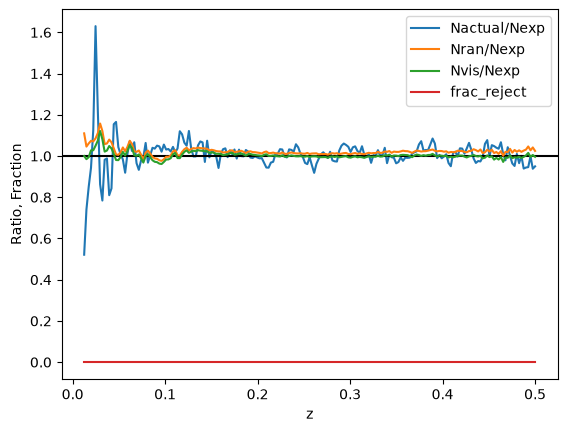

Nactual/Nexp: should fluctuate about unity with fluctuations driven by LSS in the subhalo catalogue.
Nran/Nexp: Should be close to unity 
Nvis/Nexp: Will be a little lower than Nran/Nexp as exlcudes galaxies within a slice that are not visible at zmax.  Will tend to Nran/Nexp with increasing number of bins.
frac_reject: 0 unless Rejection=True algorithm is selected.


In [22]:
#Diagnostic Plots
diagnostics=Table.read('./sdata/Mocks/diagnostics.fits')
print(diagnostics.columns)


plt.plot(
    diagnostics['zmax'],
    diagnostics['ratio_actual_expected'],label='Nactual/Nexp'
)
plt.axhline(1.0,color='k')






plt.plot(
    diagnostics['zmax'],
    ((diagnostics['Nran_slice']/diagnostics.meta['NMULT'])/diagnostics['Nexpected']),label='Nran/Nexp'
)

plt.plot(
    diagnostics['zmax'],
    ((diagnostics['Nran_vis_slice']/diagnostics.meta['NMULT'])/diagnostics['Nexpected']),label='Nvis/Nexp'
)

plt.plot(
    diagnostics['zmax'],
    diagnostics['frac_rejected'],label='frac_reject'
)



plt.xlabel('z')
plt.ylabel('Ratio, Fraction')
#plt.ylim([-0.1,1.25])
plt.legend()
plt.show()
print('Nactual/Nexp: should fluctuate about unity with fluctuations driven by LSS in the subhalo catalogue.')
print('Nran/Nexp: Should be close to unity ')
print('Nvis/Nexp: Will be a little lower than Nran/Nexp as exlcudes galaxies within a slice that are not visible at zmax.  Will tend to Nran/Nexp with increasing number of bins.')
print('frac_reject: 0 unless Rejection=True algorithm is selected.')


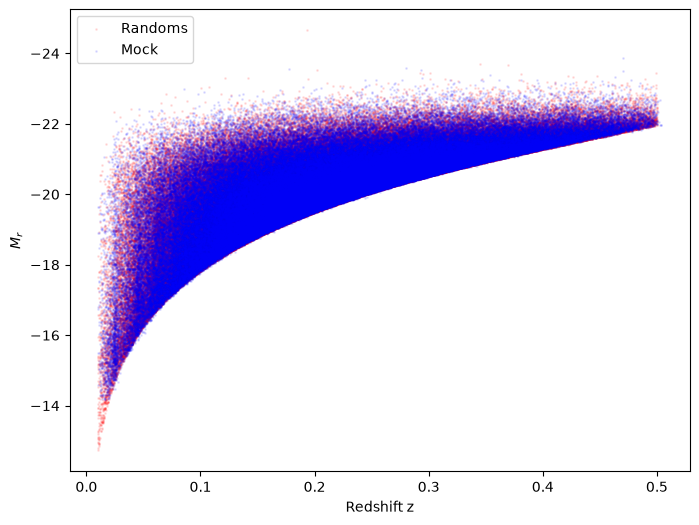

In [23]:
#Overlay of mock on randoms in the ABSMAG_RP1 Z plane

nplot = 200000 # size of random smaple to plot

ir = np.random.choice(len(randoms),  min(nplot, len(randoms)),  replace=False)
im = np.random.choice(len(mock), min(nplot, len(mock)), replace=False)

fig, ax = plt.subplots(figsize=(8,6))

ax.scatter(
    randoms['Z'][ir],
    randoms['ABSMAG_R'][ir],
    s=1,
    c='red',
    alpha=0.1,
    label='Randoms'
)

ax.scatter(
    mock['Zobs'][im],
    mock['ABSMAG_R'][im],
    s=1,
    c='blue',
    alpha=0.1,
    label='Mock'
)

ax.set_xlabel('Redshift z')
ax.set_ylabel(r'$M_r$')
ax.invert_yaxis()
ax.legend()

plt.show()

[0.273 0.279 0.285 0.291 0.297]
[0.0036631  0.0036711  0.00365528 0.0036581  0.00363721]


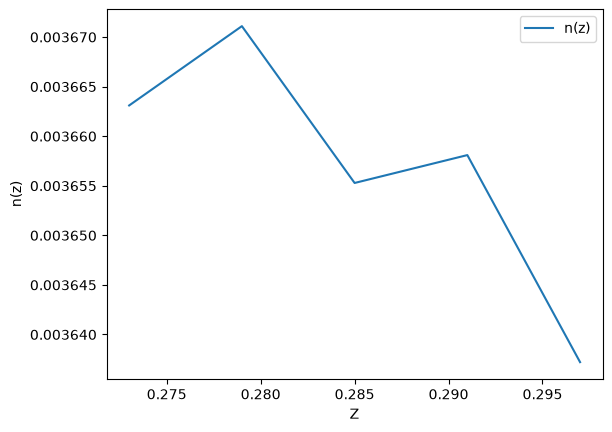

In [24]:
#Spot check that a volume limited shell has fairly constant density across it

zmax=0.3
zmin_ex=zmax-DeltaZ
nmult_formock=randoms.meta['NMULT']

edges = np.linspace(zmin_ex, zmax, 6)
zcen= (edges[1:]+edges[:-1])/2.0
n=0.0*zcen

for i in range(len(edges)-1):

    m = (
        (randoms['Z'] >= edges[i]) &
        (randoms['Z']< edges[i+1]) &
        (randoms['zmax'] >= zmax)
    )

    V = (
        fsky_formock * nmult_formock *
        (4*np.pi/3.0) *
        ( (ca.cosmo.comoving_distance(edges[i+1]).value)**3 -(ca.cosmo.comoving_distance(edges[i]).value)**3 )
    )

    n[i] = np.count_nonzero(m) / V

print(zcen)
print(n)


plt.plot(zcen,n,label='n(z)')
plt.legend()
plt.xlabel('Z')
plt.ylabel('n(z)')

plt.show()
